# Анализ данных отдела продаж маркетплейса "МаркетПро"

## 1. Описание и загрузка данных

### Описание данных

**Таблица `categories` — категории товаров**  
Содержит список категорий, которым принадлежат продукты. Внутри:  
`category_id` — уникальный ID категории;  
`name` — название категории;  
`parent_category_id` — ID родительской категории для иерархической структуры.

**Таблица `order_items` — товары в заказах**  
Содержит позиции товаров, которые были фактически проданы в конкретных заказах. Каждая строка — это товар, который был включён в заказ, с указанием количества и цены на момент покупки. Внутри:  
`order_item_id` — уникальный ID позиции заказа;  
`order_id` — ID заказа (внешний ключ на таблицу orders);  
`product_id` — ID товара (внешний ключ на таблицу products);  
`quantity` — количество единиц товара в позиции;  
`price_at_order_time` — цена товара на момент оформления заказа.  

**Таблица `orders` — заказы**
Содержит общую информацию по заказу. Внутри:    
`order_id` — уникальный ID заказа;  
`buyer_id` — ID покупателя (внешний ключ на таблицу users;  
`order_date` — дата создания заказа;  
`status` — статус заказа;  
`total_amount` — общая сумма заказа.  

**Таблица `products` — товары**  
Содержит каталог всех товаров маркетплейса, которые могут быть выставлены продавцами. Внутри:  
`product_id` — уникальный ID товара;  
`title` — название товара;  
`description` — описание товара;  
`category_id` — категория товара (внешний ключ на таблицу categories);  
`price` — цена товара;  
`stock_quantity` — количество товара в наличии;  
`seller_id` — ID продавца.

**Таблица `reviews` — отзывы**  
Содержит отзывы пользователей. Внутри:  
`review_id` — уникальный ID отзыва;  
`user_id` — ID пользователя (внешний ключ на таблицу users);  
`product_id` — ID товара (внешний ключ на таблицу products);  
`rating` — оценка товара;  
`comment` — текст отзыва;  
`review_date` — дата создания отзыва.

**Таблица `transactions` — транзакции**  
Содержит записи платежей и возвратов пользователей. Внутри:  
`transaction_id` — уникальный ID транзакции;  
`user_id` — ID пользователя (внешний ключ на таблицу users);  
`amount` — сумма платежа, может быть отрицательной в случае возврата;  
`transaction_type` — тип транзакции (refund или payment);  
`transaction_date` — дата платежа или возврата.

**Таблица `users` — пользователи**  
Содержит информацию обо всех пользователях маркетплейса. Внутри:  
`user_id` — уникальный ID пользователя;  
`name` — имя пользователя;  
`email` — электронный адрес;  
`phone` — телефон;  
`user_type` — тип пользователя (buyer или seller);  
`registration_date` — дата регистрации;  
`is_active` — активность пользователя (true или false).

### Загрузка данных

In [1]:
# Иимпортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Загружаем данные из таблиц
categories = pd.read_csv(r'C:\Users\Mi\Downloads\categories.csv')
order_items = pd.read_csv(r'C:\Users\Mi\Downloads\order_items.csv')
orders = pd.read_csv(r'C:\Users\Mi\Downloads\orders.csv')
products = pd.read_csv(r'C:\Users\Mi\Downloads\products.csv')
reviews = pd.read_csv(r'C:\Users\Mi\Downloads\reviews.csv')
transactions = pd.read_csv(r'C:\Users\Mi\Downloads\transactions.csv')
users = pd.read_csv(r'C:\Users\Mi\Downloads\users.csv')

## 2. Предобработка данных

In [3]:
## Проверяем наличие дубликатов
categories_duplicates = categories.duplicated().sum()
order_items_duplicates = order_items.duplicated().sum()
orders_duplicates = orders.duplicated().sum()
products_duplicates = products.duplicated().sum()
reviews_duplicates = reviews.duplicated().sum()
transactions_duplicates = transactions.duplicated().sum()
users_duplicates = users.duplicated().sum()

print(f'Всего дубликатов в таблице categories: {categories_duplicates}')
print(f'Всего дубликатов в таблице order_items: {order_items_duplicates}')
print(f'Всего дубликатов в таблице orders: {orders_duplicates}')
print(f'Всего дубликатов в таблице products: {products_duplicates}')
print(f'Всего дубликатов в таблице reviews: {reviews_duplicates}')
print(f'Всего дубликатов в таблице transactions: {transactions_duplicates}')
print(f'Всего дубликатов в таблице users: {users_duplicates}')

Всего дубликатов в таблице categories: 0
Всего дубликатов в таблице order_items: 0
Всего дубликатов в таблице orders: 0
Всего дубликатов в таблице products: 0
Всего дубликатов в таблице reviews: 0
Всего дубликатов в таблице transactions: 0
Всего дубликатов в таблице users: 0


**Дубликаты в таблицах остутствуют.**.

In [4]:
## Преобразуем даты их таблиц в нужный формат
orders['order_date'] = pd.to_datetime(orders['order_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
users['registration_date'] = pd.to_datetime(users['registration_date'])

In [5]:
## Заменяем ошибочные отрицательные значения на 0
products.loc[products['price'] < 0, 'price'] = 0

In [6]:
## Создаем столбец с категорией рейтинга
def categorize_rating(rating):
    if rating >= 4.5:
        return 'High'
    elif rating >= 4 and rating < 4.5:
        return 'Medium'
    else:
        return 'Low'

reviews['rating_category'] = reviews['rating'].apply(categorize_rating)

In [7]:
## Количество пропусков в таблице categories
categories.isna().sum()

category_id             0
name                    2
parent_category_id    885
dtype: int64

In [8]:
## Количество пропусков в таблице order_items
order_items.isna().sum()

order_item_id          0
order_id               0
product_id             0
quantity               0
price_at_order_time    0
dtype: int64

In [9]:
## Количество пропусков в таблице orders
orders.isna().sum()

order_id        0
buyer_id        0
order_date      0
status          0
total_amount    0
dtype: int64

In [10]:
## Количество пропусков в таблице products
products.isna().sum()

product_id         0
title             63
description        0
category_id        0
price              0
stock_quantity     0
seller_id          0
dtype: int64

In [11]:
## Количество пропусков в таблице reviews
reviews.isna().sum()

review_id          0
user_id            0
product_id         0
rating             0
comment            0
review_date        0
rating_category    0
dtype: int64

In [12]:
## Количество пропусков в таблице transactions
transactions.isna().sum()

transaction_id      0
user_id             0
amount              0
transaction_type    0
transaction_date    0
dtype: int64

In [13]:
## Количество пропусков в таблице users
users.isna().sum()

user_id              0
name                 0
email                0
phone                0
user_type            0
registration_date    0
is_active            0
dtype: int64

Большое количество пропусков присутствует лишь в столбце parent_category_id, предположительно потому, что эти категории сами являются "родительскими". Принято решение оставить пропуски.

## 3. Исследовательский анализ данных

In [14]:
## Выводим основную информацию по столбцам price и stock_quantity
products[['price', 'stock_quantity']].describe()

,price,stock_quantity
count,52100.000000,52100.000000
mean,506.569939,500.620461
std,285.605499,287.761399
min,10.020000,0.000000
25%,260.072500,254.000000
50%,507.810000,502.000000
75%,754.180000,747.000000
max,999.990000,1000.000000


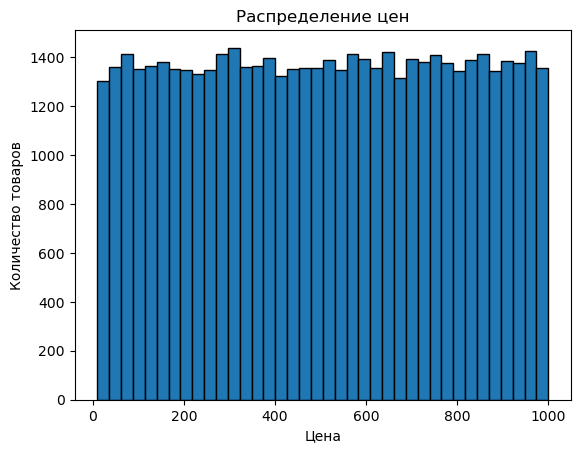

In [15]:
## Изучаем распределение цен
plt.hist(products['price'], bins='auto', edgecolor='black')

plt.title('Распределение цен')
plt.xlabel('Цена')
plt.ylabel('Количество товаров')
plt.show()

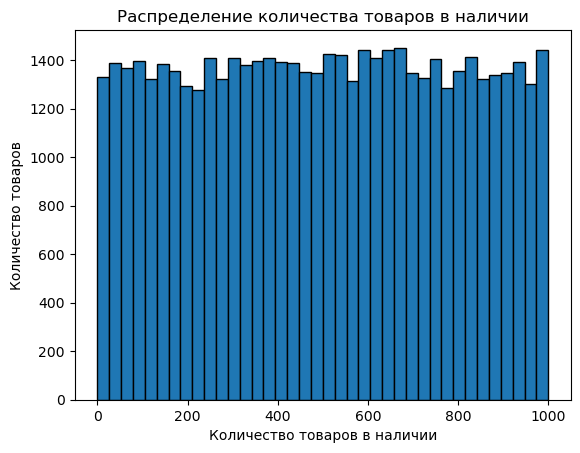

In [16]:
## Изучаем распределение количества товаров в наличии
plt.hist(products['stock_quantity'], bins='auto', edgecolor='black')

plt.title('Распределение количества товаров в наличии')
plt.xlabel('Количество товаров в наличии')
plt.ylabel('Количество товаров')
plt.show()

**Значения в столбцах `price` и `stock_quantity` распределены достаточно равномерно.**

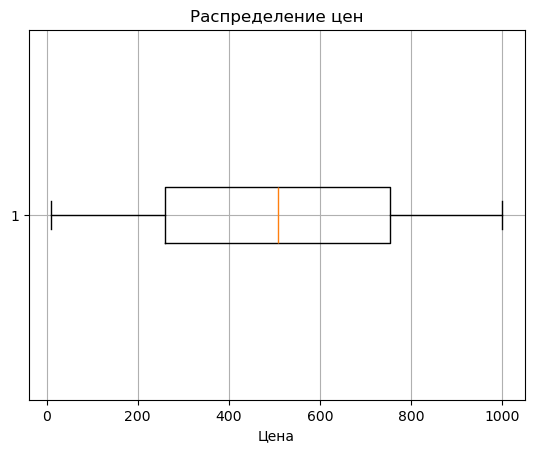

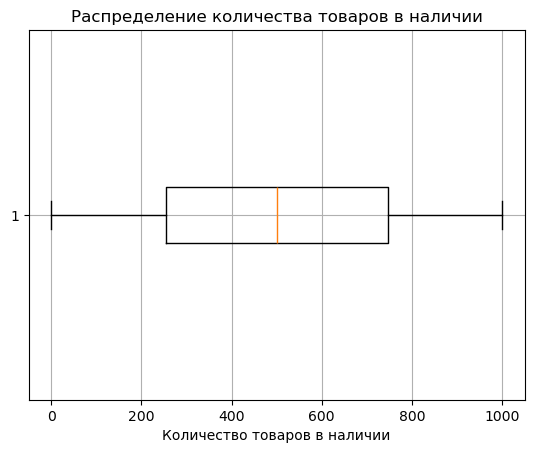

In [17]:
## Исследуем выбросы в столбце price
plt.figure()
plt.boxplot(products['price'], vert=False, flierprops=dict(markerfacecolor='red', marker='o'))
plt.title('Распределение цен')
plt.xlabel('Цена')
plt.grid(True)
plt.show()

plt.figure()
plt.boxplot(products['stock_quantity'], vert=False, flierprops=dict(markerfacecolor='red', marker='o'))
plt.title('Распределение количества товаров в наличии')
plt.xlabel('Количество товаров в наличии')
plt.grid(True)
plt.show()

**Выбросы в данных остутствуют**

In [18]:
## Вычисляем корреляционную матрицу между ценой и количеством товаров в наличии
corr_matrix = products[['price', 'stock_quantity']].corr()
corr_matrix

,price,stock_quantity
price,1.000000,0.000815
stock_quantity,0.000815,1.000000


**Линейная зависимость между двумя признаками отсутствует.**

## 4. Выгрузка данных

In [19]:
# Фильтруем заказы по дате
orders_filtered = orders[
    (orders['order_date'] >= '2025-01-01') &
    (orders['order_date'] <= '2025-06-01')
]

In [20]:
# Выгружаем данные в csv-файл
output_dir = 'exported_csv'
os.makedirs(output_dir, exist_ok=True)

orders_path = os.path.join(output_dir, 'orders_filtered.csv')
orders_filtered.to_csv(orders_path, index=False)

print(f"Таблица заказов успешно выгружена: {orders_path}")
print(f"Строк: {orders_filtered.shape[0]}, Колонок: {orders_filtered.shape[1]}")

Таблица заказов успешно выгружена: exported_csv\orders_filtered.csv
Строк: 246456, Колонок: 5
